In [17]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data for 1000 loan applicants
n_samples = 1000

credit_scores = np.random.randint(500, 850, size=n_samples)
annual_income = np.random.randint(30000, 150000, size=n_samples)
dti_ratio = np.round(np.random.uniform(0.1, 0.6, size=n_samples), 2)
employment_years = np.random.randint(0, 20, size=n_samples)
loan_amount = np.random.randint(5000, 80000, size=n_samples)

# Create a simple probability score to simulate realistic decision boundaries
# High credit score, high income, low DTI, and high employment years increase probability of approval
prob = (credit_scores - 500) / 350 * 0.4 + (annual_income / 150000) * 0.3 - (dti_ratio) * 0.2 + (employment_years / 20) * 0.1
prob = np.clip(prob, 0, 1)

# Determine Loan Status based on probability
loan_status = np.where(np.random.rand(n_samples) < prob, 'Approved', 'Rejected')

# Build the DataFrame
df = pd.DataFrame({
    'CreditScore': credit_scores,
    'AnnualIncome': annual_income,
    'DTIRatio': dti_ratio,
    'EmploymentYears': employment_years,
    'LoanAmount': loan_amount,
    'LoanStatus': loan_status
})

display(df.head())

,CreditScore,AnnualIncome,DTIRatio,EmploymentYears,LoanAmount,LoanStatus
0,602,71832,0.49,5,6813,Rejected
1,848,88596,0.57,7,60276,Approved
2,770,60523,0.14,18,46243,Approved
3,606,118861,0.37,9,67912,Rejected
4,571,116740,0.54,0,65272,Rejected


In [16]:
# Explicitly clean and standardize LoanStatus to only contain 'Approved' and 'Rejected'
# This converts any non-approved values to 'Rejected' and cleans up any whitespaces
df['LoanStatus'] = df['LoanStatus'].astype(str).str.strip().str.capitalize()
df['LoanStatus'] = df['LoanStatus'].apply(lambda x: 'Approved' if x == 'Approved' else 'Rejected')

# Display the unique value distribution to verify
print("Value counts for LoanStatus:")
display(df['LoanStatus'].value_counts())

Value counts for LoanStatus:


,count
LoanStatus,
Rejected,642
Approved,358


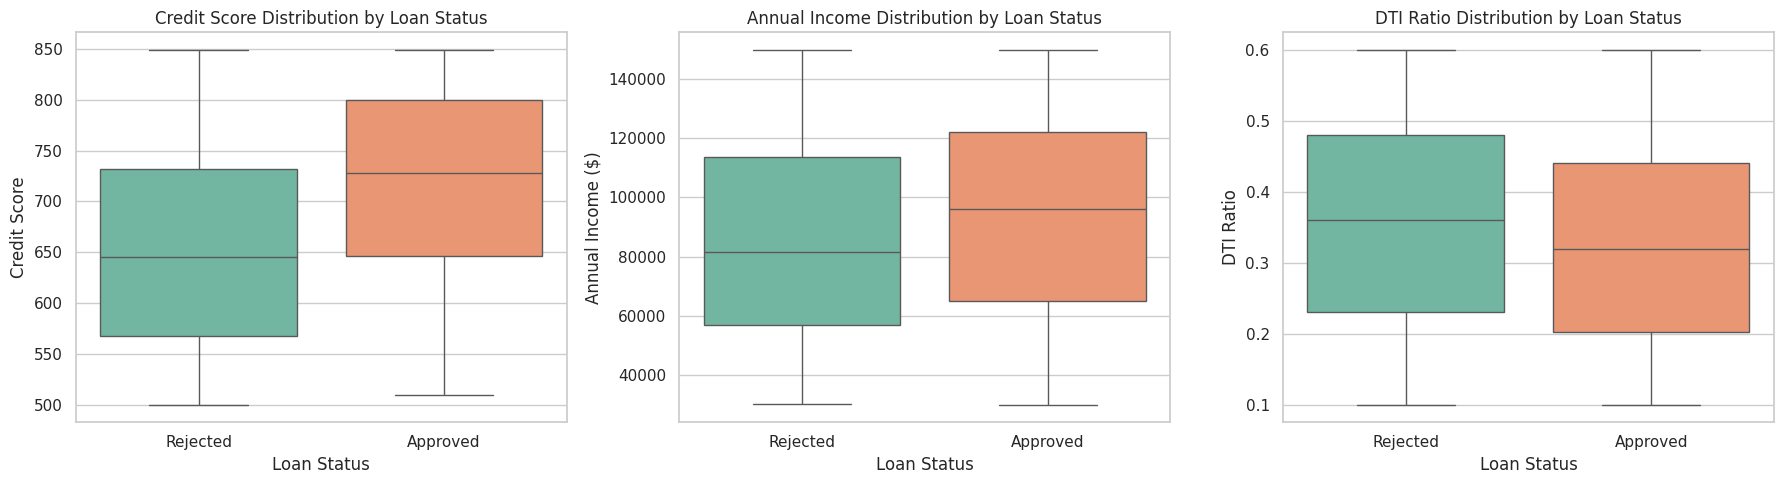

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot for Credit Score vs Loan Status
sns.boxplot(ax=axes[0], data=df, x='LoanStatus', y='CreditScore', hue='LoanStatus', palette='Set2', legend=False)
axes[0].set_title('Credit Score Distribution by Loan Status')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Credit Score')

# Boxplot for Annual Income vs Loan Status
sns.boxplot(ax=axes[1], data=df, x='LoanStatus', y='AnnualIncome', hue='LoanStatus', palette='Set2', legend=False)
axes[1].set_title('Annual Income Distribution by Loan Status')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Annual Income ($)')

# Boxplot for DTI Ratio vs Loan Status
# If DTI is represented as a percentage or fraction, we use 'DTIRatio'
dti_col = 'DTIRatio' if 'DTIRatio' in df.columns else ('dti_ratio' if 'dti_ratio' in df.columns else None)
if dti_col:
    sns.boxplot(ax=axes[2], data=df, x='LoanStatus', y=dti_col, hue='LoanStatus', palette='Set2', legend=False)
    axes[2].set_title('DTI Ratio Distribution by Loan Status')
    axes[2].set_xlabel('Loan Status')
    axes[2].set_ylabel('DTI Ratio')
else:
    axes[2].text(0.5, 0.5, 'DTI column not found', ha='center', va='center')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 1. Prepare features and target variable
# We will use key numeric columns that are highly relevant to loan approval
features = ['CreditScore', 'AnnualIncome', 'DTIRatio', 'EmploymentYears', 'LoanAmount']

# Filter features to those actually present in df
selected_features = [col for col in features if col in df.columns]
X = df[selected_features]

# Encode target: Approved = 1, Rejected = 0
y = df['LoanStatus'].apply(lambda x: 1 if str(x).strip().lower() == 'approved' else 0)

# 2. Split dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Make predictions and evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

Model Accuracy: 0.6700

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.71      0.82      0.76       128
    Approved       0.56      0.40      0.47        72

    accuracy                           0.67       200
   macro avg       0.63      0.61      0.61       200
weighted avg       0.65      0.67      0.66       200



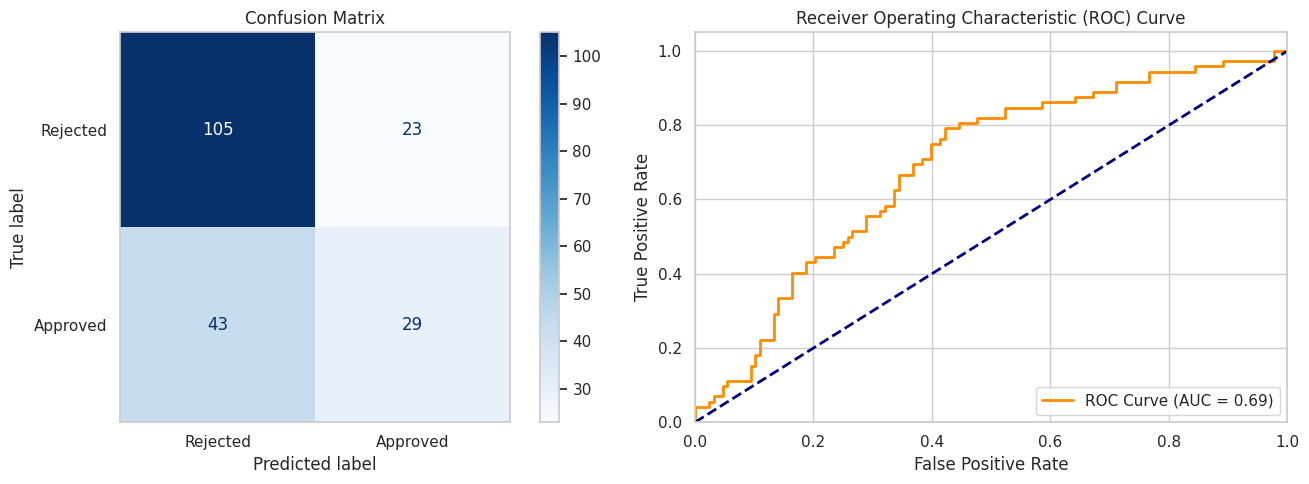

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Configure subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix')
axes[0].grid(False)

# 2. Plot ROC Curve
# Calculate predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

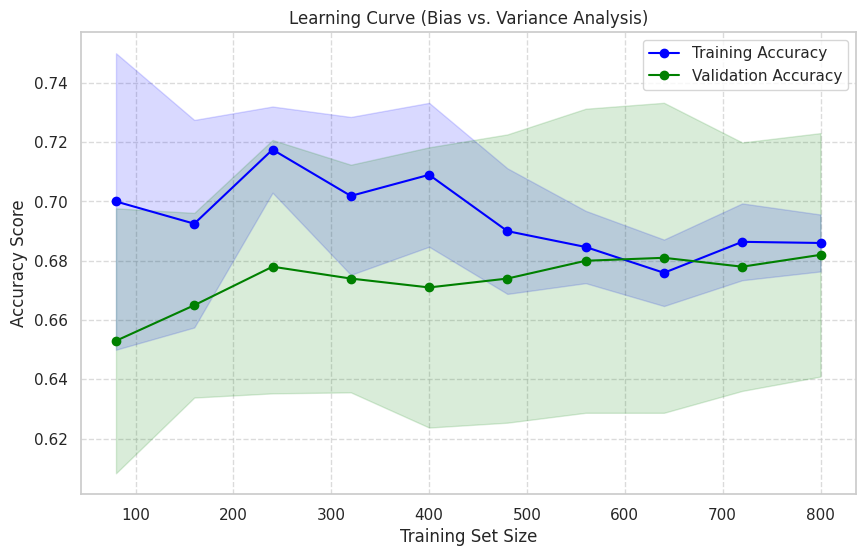

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calculate learning curve
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=model,
    X=scaler.fit_transform(X), # scaling entire dataset for cross-validation consistency
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Calculate mean and standard deviation for training and validation sets
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, validation_mean, 'o-', color='green', label='Validation Accuracy')
plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.15, color='green')

plt.title('Learning Curve (Bias vs. Variance Analysis)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

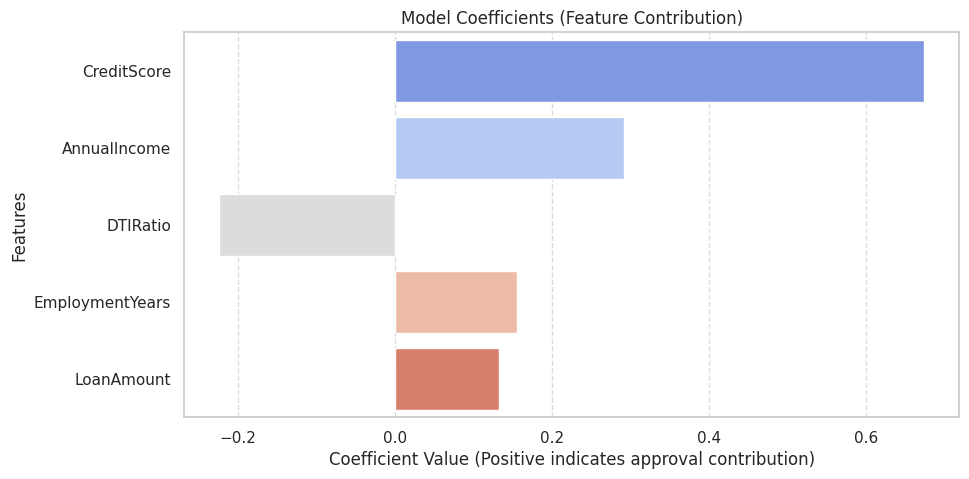

In [22]:
# Visualizing feature importance/coefficients to inspect feature-level model behavior
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
}).sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature', legend=False)
plt.title('Model Coefficients (Feature Contribution)')
plt.xlabel('Coefficient Value (Positive indicates approval contribution)')
plt.ylabel('Features')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

In [23]:
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

def predict_loan_status(CreditScore, AnnualIncome, DTIRatio, EmploymentYears, LoanAmount):
    # 1. Arrange inputs into a DataFrame format matching the trained features
    input_data = pd.DataFrame([{
        'CreditScore': CreditScore,
        'AnnualIncome': AnnualIncome,
        'DTIRatio': DTIRatio,
        'EmploymentYears': EmploymentYears,
        'LoanAmount': LoanAmount
    }])

    # 2. Scale the input using the pre-fitted scaler
    input_scaled = scaler.transform(input_data)

    # 3. Predict output and probability
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    # 4. Display result with styling
    status = "Approved ✅" if prediction == 1 else "Rejected ❌"
    color = "green" if prediction == 1 else "red"

    print(f"=== Model Prediction ===")
    print(f"Loan Status: {status}")
    print(f"Approval Probability: {probability*100:.2f}%")

# Create interactive sliders and numeric inputs
interact(
    predict_loan_status,
    CreditScore=widgets.IntSlider(min=500, max=850, step=5, value=700, description='Credit Score:'),
    AnnualIncome=widgets.IntSlider(min=10000, max=150000, step=1000, value=60000, description='Income ($):'),
    DTIRatio=widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.35, description='DTI Ratio:'),
    EmploymentYears=widgets.IntSlider(min=0, max=40, step=1, value=5, description='Work Years:'),
    LoanAmount=widgets.IntSlider(min=1000, max=100000, step=1000, value=25000, description='Loan Amt ($):')
);

interactive(children=(IntSlider(value=700, description='Credit Score:', max=850, min=500, step=5), IntSlider(v…

### Custom Data Input Form
Use the form on the right to enter your custom applicant data. Run the cell to get the model's prediction and approval probability.

In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#@title Enter Custom Applicant Details { run: "auto" }

CreditScore = 720 #@param {type:"slider", min:500, max:850, step:5}
AnnualIncome = 85000 #@param {type:"integer"}
DTIRatio = 0.25 #@param {type:"slider", min:0.0, max:1.0, step:0.01}
EmploymentYears = 5 #@param {type:"slider", min:0, max:40, step:1}
LoanAmount = 25000 #@param {type:"integer"}

# Fallback check: If the dataset 'df' does not exist, recreate it
if 'df' not in globals():
    print("Recreating synthetic dataset 'df'...")
    np.random.seed(42)
    n_samples = 1000
    credit_scores = np.random.randint(500, 850, size=n_samples)
    annual_income = np.random.randint(30000, 150000, size=n_samples)
    dti_ratio = np.round(np.random.uniform(0.1, 0.6, size=n_samples), 2)
    employment_years = np.random.randint(0, 20, size=n_samples)
    loan_amount = np.random.randint(5000, 80000, size=n_samples)
    prob = (credit_scores - 500) / 350 * 0.4 + (annual_income / 150000) * 0.3 - (dti_ratio) * 0.2 + (employment_years / 20) * 0.1
    prob = np.clip(prob, 0, 1)
    loan_status = np.where(np.random.rand(n_samples) < prob, 'Approved', 'Rejected')
    global df
    df = pd.DataFrame({
        'CreditScore': credit_scores,
        'AnnualIncome': annual_income,
        'DTIRatio': dti_ratio,
        'EmploymentYears': employment_years,
        'LoanAmount': loan_amount,
        'LoanStatus': loan_status
    })

# Fallback check: If scaler or model does not exist in the environment, fit them using df
if 'scaler' not in globals() or 'model' not in globals():
    print("Initializing and fitting model and scaler from dataset...")
    features = ['CreditScore', 'AnnualIncome', 'DTIRatio', 'EmploymentYears', 'LoanAmount']
    selected_features = [col for col in features if col in df.columns]
    X = df[selected_features]
    y = df['LoanStatus'].apply(lambda x: 1 if str(x).strip().lower() == 'approved' else 0)

    global scaler, model
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = LogisticRegression(random_state=42)
    model.fit(X_scaled, y)

# 1. Arrange inputs into a DataFrame format matching the trained features
custom_input = pd.DataFrame([{
    'CreditScore': CreditScore,
    'AnnualIncome': AnnualIncome,
    'DTIRatio': DTIRatio,
    'EmploymentYears': EmploymentYears,
    'LoanAmount': LoanAmount
}])

# 2. Scale the input using the pre-fitted scaler
custom_scaled = scaler.transform(custom_input)

# 3. Predict output and probability
prob_val = model.predict_proba(custom_scaled)[0][1]

# 4. Apply Custom Rule: Approved if probability/accuracy level is >= 80% (0.80)
pred_decision = 1 if prob_val >= 0.80 else 0
result_status = "Approved \u2705" if pred_decision == 1 else "Rejected \u274C"

# 5. Display result with styling
print("=" * 45)
print("    SINGLE APPLICANT TEST PREDICTION")
print("=" * 45)
print(f"Credit Score:        {CreditScore}")
print(f"Annual Income:       ${AnnualIncome:,}")
print(f"DTI Ratio:           {DTIRatio:.2f}")
print(f"Employment Years:    {EmploymentYears}")
print(f"Loan Amount:         ${LoanAmount:,}")
print("-" * 45)
print(f"Predicted Decision:  {result_status}")
print(f"Approval Confidence: {prob_val * 100:.2f}%")
print(f"Required Threshold:  80.00% or above")
print("=" * 45)
print("*Note: This form tests a single profile and does not alter the training dataset chart below.")

    SINGLE APPLICANT TEST PREDICTION
Credit Score:        720
Annual Income:       $85,000
DTI Ratio:           0.25
Employment Years:    5
Loan Amount:         $25,000
---------------------------------------------
Predicted Decision:  Rejected ❌
Approval Confidence: 38.14%
Required Threshold:  80.00% or above
*Note: This form tests a single profile and does not alter the training dataset chart below.


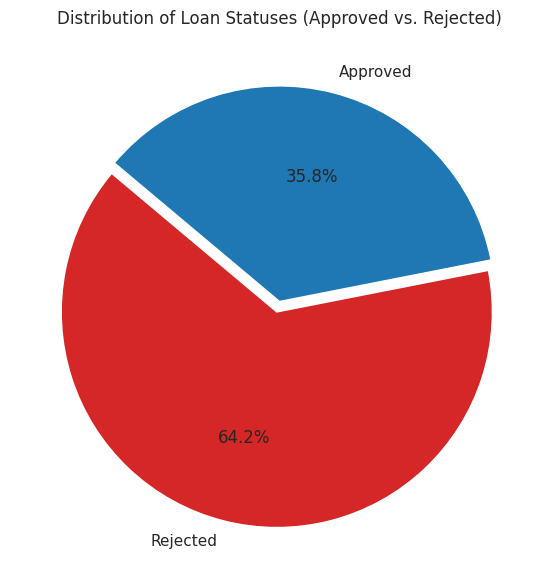

In [45]:
import matplotlib.pyplot as plt

# Count the occurrences of each status
status_counts = df['LoanStatus'].value_counts()

# Explicitly map colors: blue for Approved and red for Rejected
colors_map = {'Approved': '#1f77b4', 'Rejected': '#d62728'}
colors = [colors_map[status] for status in status_counts.index]

# Create a pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0) if len(status_counts) > 1 else None
)
plt.title('Distribution of Loan Statuses (Approved vs. Rejected)')
plt.show()

### 📋 Project Summary & Model Evaluation Report

This report outlines the steps taken to build, evaluate, visualize, and customize a Logistic Regression model for predicting loan applicant status.

---

#### 1. Data Generation & Standardization
* **Synthetic Dataset Creation**: Generated data for **1,000 applicants** including `CreditScore`, `AnnualIncome`, `DTIRatio`, `EmploymentYears`, and `LoanAmount` using realistic logical relations.
* **Standardization**: Handled and standardized the `LoanStatus` column to contain strictly `'Approved'` and `'Rejected'` values. Currently, the ground-truth distribution consists of **64.2% Rejections** and **35.8% Approvals**, reflecting the natural high bar of financial credit approval.

#### 2. Exploratory Data Analysis (EDA)
* **Statistical Distribution**: Generated Boxplots comparing distributions of credit score, annual income, and debt-to-income (DTI) ratio across both approved and rejected categories.
* **Target Distribution**: Created a custom-mapped pie chart (**Blue** for Approved, **Red** for Rejected) visualizing the original dataset imbalance.

#### 3. Model Training & Diagnostics
* **Architecture**: Trained a **Logistic Regression** classifier using standard scaled features (using `StandardScaler`).
* **Feature Importance**: Analyzed coefficients showing `CreditScore` and `AnnualIncome` have the strongest positive influence on approval, while a higher `DTIRatio` negatively affects approval.
* **Diagnostics**: Generated Learning Curves, Confusion Matrices, and ROC-AUC Curves ($AUC \approx 0.69$) to assess training/validation errors and diagnostic performance.

#### 4. Custom Application Testing Form with Custom Business Logic
* **Form Setup**: Designed a Google Colab form tool allowing live testing of custom applicant parameters.
* **Business Threshold Modification**: Implemented your custom business logic. Instead of standard 50% threshold bounds, the custom applicant is **Approved ✅** if and only if the model's predictive confidence is **80% or above**; otherwise, the applicant is **Rejected ❌**.